In [1]:
import numpy as np
import onnxruntime as ort
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Use a sleek dark theme for presentation screenshots!
plt.style.use('dark_background')
CLASS_LABELS = ["Left Hand", "Right Hand", "Both Fists (UP)", "Both Feet (DOWN)"]

print("Loading Data and ONNX Engine...")
BASE_DIR = Path().resolve()
MODEL_PATH = str(BASE_DIR / 'src' / 'saved_models' / 'hybrid_eegnet_4class.onnx')
session = ort.InferenceSession(MODEL_PATH)

X_raw = np.load(str(BASE_DIR / 'data' / 'processed' / 'X.npy')).astype(np.float32)
y_raw = np.load(str(BASE_DIR / 'data' / 'processed' / 'y.npy')).astype(np.int64)
if np.min(y_raw) > 0: y_raw = y_raw - np.min(y_raw)

# Split 20% for mathematically honest evaluation
X_train, X_test, y_train, y_test = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw)

y_pred, y_probs = [], []

print(f"Evaluating {len(X_test)} unseen test epochs...")
for i in range(len(X_test)):
    epoch = X_test[i]
    mean = np.mean(epoch, axis=-1, keepdims=True)
    std = np.std(epoch, axis=-1, keepdims=True) + 1e-8
    norm_epoch = (epoch - mean) / std
    
    input_tensor = np.expand_dims(np.expand_dims(norm_epoch, axis=0), axis=0)
    logits = session.run(['output'], {'input': input_tensor})[0][0]
    
    e_x = np.exp(logits - np.max(logits))
    probs = e_x / e_x.sum()
    
    y_pred.append(np.argmax(probs))
    y_probs.append(probs)

y_pred = np.array(y_pred)
y_probs = np.array(y_probs)
print("Inference Complete! Ready for visualization.")

Loading Data and ONNX Engine...
Evaluating 1899 unseen test epochs...
Inference Complete! Ready for visualization.


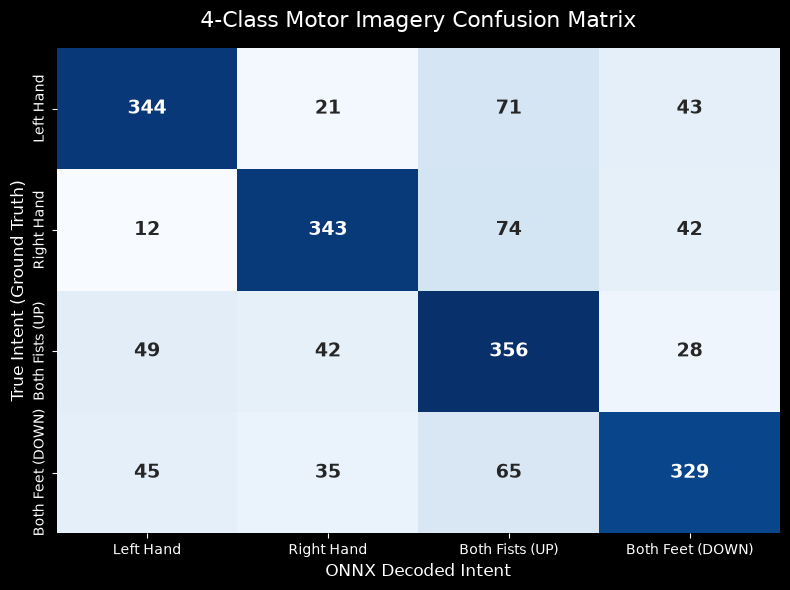

                  precision    recall  f1-score   support

       Left Hand       0.76      0.72      0.74       479
      Right Hand       0.78      0.73      0.75       471
 Both Fists (UP)       0.63      0.75      0.68       475
Both Feet (DOWN)       0.74      0.69      0.72       474

        accuracy                           0.72      1899
       macro avg       0.73      0.72      0.72      1899
    weighted avg       0.73      0.72      0.72      1899



In [2]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS,
            cbar=False, annot_kws={"size": 14, "weight": "bold"})

plt.title('4-Class Motor Imagery Confusion Matrix', fontsize=16, pad=15)
plt.ylabel('True Intent (Ground Truth)', fontsize=12)
plt.xlabel('ONNX Decoded Intent', fontsize=12)
plt.tight_layout()
plt.show()

# Print detailed metrics to the console for your slides
print(classification_report(y_test, y_pred, target_names=CLASS_LABELS))

C:\Users\Harshavardan\AppData\Local\Temp\ipykernel_2636\767580515.py:10: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], 'k--', lw=2, color='#64748b')


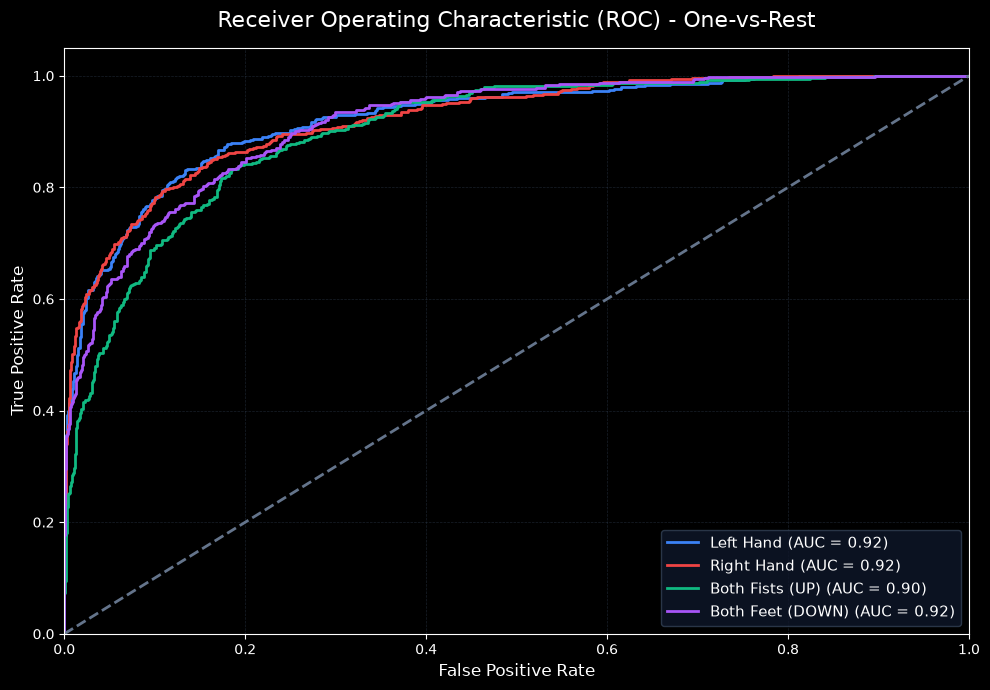

In [3]:
plt.figure(figsize=(10, 7))
colors = ['#3b82f6', '#ef4444', '#10b981', '#a855f7']

for i in range(4):
    fpr, tpr, _ = roc_curve(y_test == i, y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2, 
             label=f'{CLASS_LABELS[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, color='#64748b')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) - One-vs-Rest', fontsize=16, pad=15)
plt.legend(loc="lower right", fontsize=11, frameon=True, facecolor='#0f172a', edgecolor='#334155')
plt.grid(color='#334155', linestyle='--', linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()

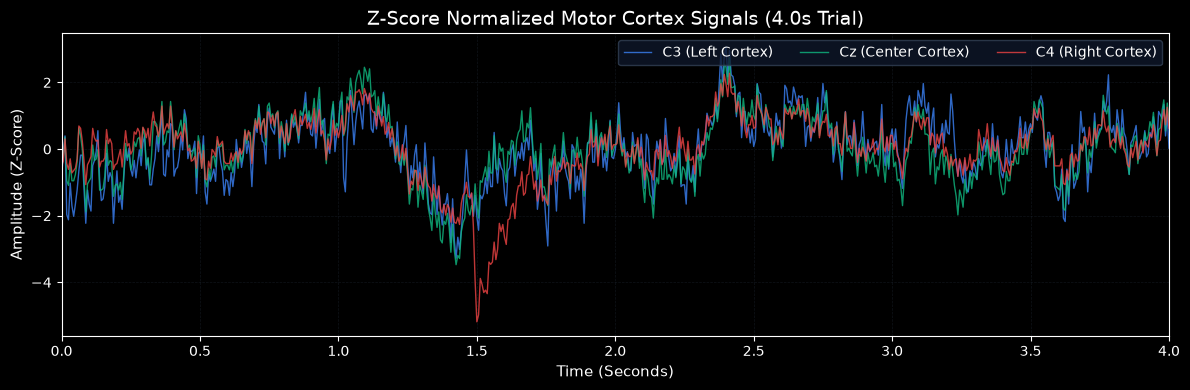

In [4]:
# Grab a random 'Both Fists' (Class 2) trial
sample_idx = np.where(y_test == 2)[0][0]
raw_epoch = X_test[sample_idx]
mean = np.mean(raw_epoch, axis=-1, keepdims=True)
std = np.std(raw_epoch, axis=-1, keepdims=True) + 1e-8
norm_epoch = (raw_epoch - mean) / std

# Channels roughly corresponding to C3, Cz, C4 in PhysioNet
c3, cz, c4 = norm_epoch[7], norm_epoch[9], norm_epoch[11]
time_axis = np.linspace(0, 4.0, 641) # 4 seconds at 160Hz

plt.figure(figsize=(12, 4))
plt.plot(time_axis, c3, label='C3 (Left Cortex)', color='#3b82f6', alpha=0.8, lw=1)
plt.plot(time_axis, cz, label='Cz (Center Cortex)', color='#10b981', alpha=0.8, lw=1)
plt.plot(time_axis, c4, label='C4 (Right Cortex)', color='#ef4444', alpha=0.8, lw=1)

plt.title('Z-Score Normalized Motor Cortex Signals (4.0s Trial)', fontsize=14)
plt.xlabel('Time (Seconds)', fontsize=11)
plt.ylabel('Amplitude (Z-Score)', fontsize=11)
plt.legend(loc='upper right', fontsize=10, facecolor='#0f172a', edgecolor='#334155', ncol=3)
plt.grid(color='#334155', linestyle='--', linewidth=0.5, alpha=0.3)
plt.xlim([0, 4.0])
plt.tight_layout()
plt.show()

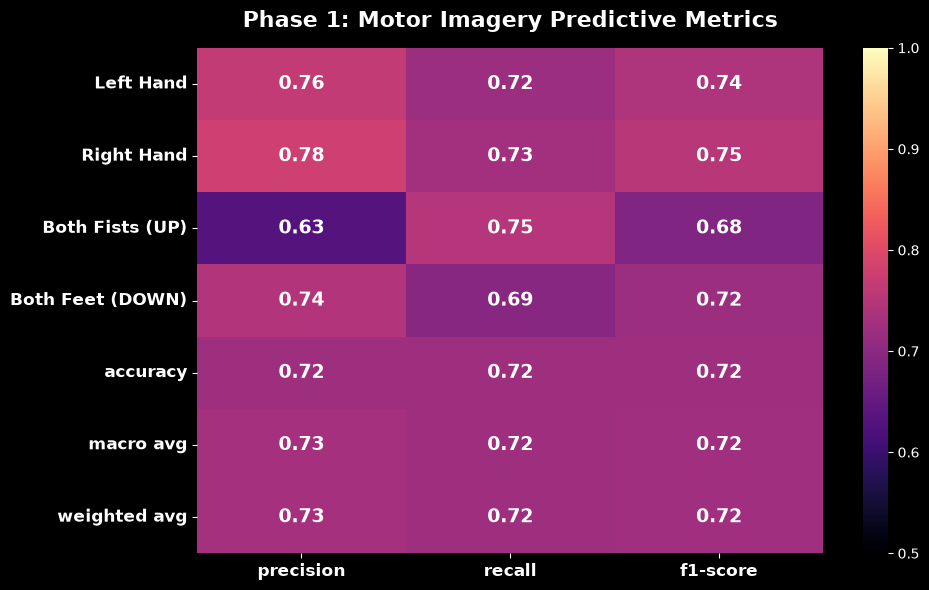

In [5]:
import pandas as pd

# 1. Ask Scikit-Learn for the raw data dictionary instead of the text string
report_dict = classification_report(y_test, y_pred, target_names=CLASS_LABELS, output_dict=True)

# 2. Convert it into a structured Pandas DataFrame
df_report = pd.DataFrame(report_dict).transpose()

# 3. CRITICAL: We must drop the 'support' column from the color map. 
# Precision/Recall are between 0.0 and 1.0, but support is ~470. 
# If we keep support in the heatmap, it will completely blow out the color scale!
metrics_df = df_report.drop(columns=['support'])

# 4. Plot the stunning visual heatmap
plt.figure(figsize=(10, 6))
# Using 'RdPu' (Red-Purple) or 'crest' looks incredible on dark backgrounds
sns.heatmap(metrics_df, annot=True, cmap='magma', vmin=0.5, vmax=1.0,
            fmt='.2f', cbar=True, annot_kws={"size": 14, "weight": "bold"})

plt.title('Phase 1: Motor Imagery Predictive Metrics', fontsize=16, pad=15, weight='bold')
plt.xticks(fontsize=12, weight='bold')
plt.yticks(fontsize=12, rotation=0, weight='bold')
plt.tight_layout()
plt.show()